<a href="https://colab.research.google.com/github/johnsiega/Machine-Learning-Experiments/blob/main/SiegaWW2_datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##DATA CLEANING PIPELINE

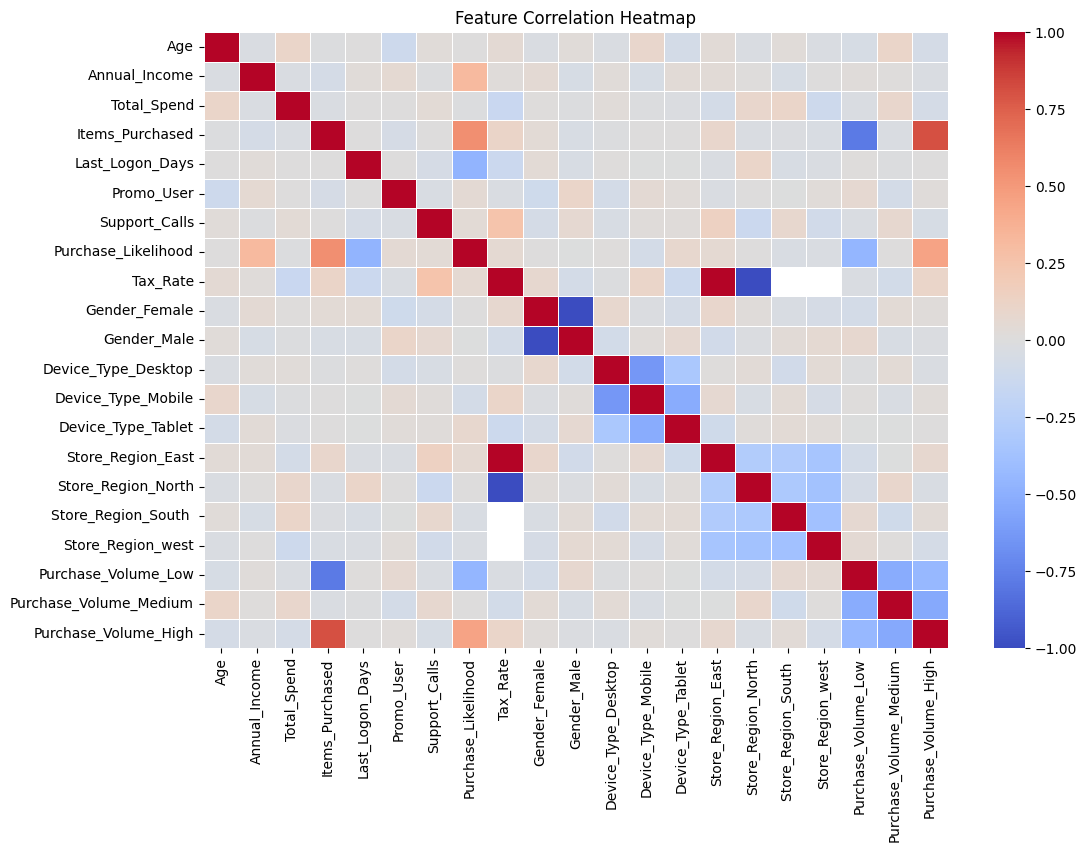

low_corr_cols ['Age', 'Total_Spend', 'Promo_User', 'Support_Calls', 'Tax_Rate', 'Gender_Female', 'Gender_Male', 'Device_Type_Desktop', 'Store_Region_East', 'Store_Region_North', 'Store_Region_South ', 'Store_Region_west', 'Purchase_Volume_Medium']
corr_series: Age                       0.002114
Annual_Income             0.318650
Total_Spend               0.013397
Items_Purchased           0.548262
Last_Logon_Days           0.470791
Promo_User                0.047992
Support_Calls             0.042026
Purchase_Likelihood       1.000000
Tax_Rate                  0.057420
Gender_Female             0.005396
Gender_Male               0.005396
Device_Type_Desktop       0.013304
Device_Type_Mobile        0.076795
Device_Type_Tablet        0.079528
Store_Region_East         0.062349
Store_Region_North        0.003349
Store_Region_South        0.036860
Store_Region_west         0.023665
Purchase_Volume_Low       0.459090
Purchase_Volume_Medium    0.002212
Purchase_Volume_High      0.451011
Name

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('adjusted_noisy_knn_300.csv')

df = df.drop_duplicates(subset=['Customer_ID'])

df.loc[(df['Age']>100) | (df['Age'] <0), 'Age'] = np.nan
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income' ].median())
df['Total_Spend'] = df['Total_Spend'].fillna(df['Total_Spend'].median())

df['Gender'] = df['Gender'].str.strip().str.lower().replace({
'm': 'Male', 'male': 'Male', 'f': 'Female', 'female': 'Female', 'fem': 'Female'
})
df['Device_Type'] = df['Device_Type'].str.strip().str.capitalize()

df['Purchase_Volume'] = pd.cut(df['Items_Purchased'],
bins=[0, 15, 35, 51],
labels=['Low', 'Medium', 'High'])

region_tax_data = pd.DataFrame({
'Store_Region': ['North', 'South', 'East', 'West'],
'Tax_Rate': [0.05, 0.07, 0.06, 0.08]
})
df = pd.merge(df, region_tax_data, on='Store_Region', how='left')

scaler = MinMaxScaler()
numeric_cols = ['Age', 'Annual_Income', 'Total_Spend', 'Items_Purchased',
'Last_Logon_Days', 'Support_Calls', 'Tax_Rate']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df = pd.get_dummies(df, columns=['Gender', 'Device_Type', 'Store_Region', 'Purchase_Volume'])

cols_to_drop = ['Membership_Score', 'Newsletter_Sub', 'Customer_ID', 'Purchase_Date']
df_final = df.drop(columns=cols_to_drop)



# 3. Heatmap Visualization (New Section)
if 'Purchase_Likelihood' in df_final.columns:
    plt.figure(figsize=(12, 8))
    # Calculating correlation for the heatmap
    full_corr = df_final.corr()

    # Plotting the heatmap
    sns.heatmap(full_corr, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.show()

    # 4. Feature Selection based on Correlation
    corr_series = full_corr['Purchase_Likelihood'].abs()
    low_corr_cols = corr_series[(corr_series < 0.07) & (corr_series.index != 'Purchase_Likelihood')].index.tolist()
    print ("low_corr_cols", low_corr_cols)
    print ("corr_series:", corr_series)
    if low_corr_cols:

        df_final = df_final.drop(columns=low_corr_cols)
        print("Dropped low-correlation columns:", low_corr_cols)

# Save the prepared dataset
df_final.to_csv('cleaned_data.csv', index=False)
print("Data Preparation Complete. Final shape:", df_final.shape)



##PHASE 2
###Building the Pipeline

###Cell 1: Library Initialization for Data Science and Visualization
####Purpose: These libraries provide the pre-built functions necessary to transform raw data into a clean, scaled, and visualized format ready for a Machine Learning model.




*   pandas as pd: Library for working with tables/dataframes (like Excel in Python) and pd is it's instance so it will be called when we need pandas.
*   numpy as np: Library for mathematical operations and arrays. np is its instance so np will be called when numpy is used.
*   MinMaxScaler: Tool from scikit-learn that scales numbers to a range (we'll use 0-1)






*   import seaborn as sns & import matplotlib.pyplot as plt – Loads the visualization duo used to create the correlation heatmap and other charts that make data patterns visible to the human eye.






*   pd.read_csv() - as mentioned in cell one, pd is called to read the csv files we just uploaded and converts it to a DataFramme (table)
*   df - Short for "dataframe", standard variable name for a data table.
*   This loads all 300 rows and 15 columns into google colab memory





In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('adjusted_noisy_knn_300.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst rows:\n{df.head()}")

Shape: (300, 15)

Columns:
['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Purchase_Date', 'Membership_Score', 'Total_Spend', 'Store_Region', 'Items_Purchased', 'Last_Logon_Days', 'Promo_User', 'Device_Type', 'Support_Calls', 'Newsletter_Sub', 'Purchase_Likelihood']

Missing values:
Customer_ID              0
Age                     70
Gender                   0
Annual_Income            0
Purchase_Date            0
Membership_Score         0
Total_Spend            212
Store_Region             0
Items_Purchased          0
Last_Logon_Days          0
Promo_User               0
Device_Type              0
Support_Calls            0
Newsletter_Sub           0
Purchase_Likelihood      0
dtype: int64

First rows:
  Customer_ID    Age  Gender  Annual_Income Purchase_Date  Membership_Score  \
0      C-1000   58.0    Male   69934.283060   Oct 1, 2023          0.468979   
1      C-1001   19.0       m   72953.770762    2023-10-01          0.491412   
2      C-1002    NaN  Female   55316.932506  

###Cell 2 Remove Duplicates
####Purpose: One customer should appear only once. Removes duplicate Customer_IDs.



*   drop_duplicates()- I think the syntax speaks for itself that it finds duplicate rows and remove them.
*   subset = ['Customer_ID'] - Only looks at Customer_ID column to determine duplicates
*   If two rows have same Customer_ID, keep first one, delete the rest
*   Why? Same customer shouldn't appear twice - the model would be biased towards the customer that reappered





In [ ]:
df = df.drop_duplicates(subset=['Customer_ID'])
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (286, 15)


### Cell 3: Handle Outliers
####Purpose: Replace impossible values (negative age, age > 100, negative income) with NaN. We'll fill these later.


*   df.loc[...] - Locate and modify specific rows in the dataframe
*   (df['Age'] < 100) - Finds all rows where Age is greater than 100
*   "|" - Means "OR" (Logical OR) checks if one or the other parameter or constraint fits
*   (df['Age'] < -) -Finds all rows where Age is less than 0
*   'Age'] = np.nan -set those Age values to NaN (Not a Number = missing)
*   Why? Ages like 200 or -10 are impossible, they're data errors







In [ ]:
df.loc[(df['Age'] > 100) | (df['Age'] < 0), 'Age'] = np.nan
df.loc[df['Annual_Income'] < 0, 'Annual_Income'] = np.nan
print(f"Outliers converted to NaN")
print(f"Age nulls: {df['Age'].isnull().sum()}")
print(f"Income nulls: {df['Annual_Income'].isnull().sum()}")

Outliers converted to NaN
Age nulls: 223
Income nulls: 1


###Cell 4:Impute Missing Values
####Purpose Fill missing values with median(Middle value, not affected by outliers). Alternative: could use mean or mode.



*   Same logic as above
*   Finds rows where Annual_Income is negative
*   Sets those values to NaN
*   Why? You can't have negative income in this context (it's not debt)







*   df['Age'].median() - Calculates the middle value of all Ages (Ignoring NaN)
*   .fillna() - "Fill the NaN values with..."
*   So it replaces all NaN ages with the median age
*   Why median instead of mean? Median isn't affected by outliers. If you had ages 20, 25, 30, 200, median is still ~25, but mean would be skewed





*   Same logic for Total_Spend column
*   Note: This column had 212 missing values originally!



In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Total_Spend'] = df['Total_Spend'].fillna(df['Total_Spend'].median())
print(f"Missing values after imputation:\n{df.isnull().sum()}")

Missing values after imputation:
Customer_ID            0
Age                    0
Gender                 0
Annual_Income          0
Purchase_Date          0
Membership_Score       0
Total_Spend            0
Store_Region           0
Items_Purchased        0
Last_Logon_Days        0
Promo_User             0
Device_Type            0
Support_Calls          0
Newsletter_Sub         0
Purchase_Likelihood    0
dtype: int64


###Cell 6: Standardize Device_Type
####Purpose: Fix "mobile", "Mobile ", "TABLET" into consistent capitalization: Mobile, Desktop, Tablet.




*  .str.strip() - Remove spaces ("Mobile " becomes "Mobile")
*   .str.capitalize() - First letter uppercase, rest lowercase
*   "mobile" → "Mobile", "TABLET" → "Tablet", "Desktop" → "Desktop"
*   Why? Consistent formatting - "mobile" and "Mobile" should be treated as the same



In [ ]:
df['Device_Type'] = df['Device_Type'].str.strip().str.capitalize()
print(f"Unique Device_Type values: {df['Device_Type'].unique()}")

Unique Device_Type values: ['Tablet' 'Desktop' 'Mobile']


###Cell 7: Create Purchase Volume Categories
####Purpose: Bin continuous values into categories. 0-15 items = Low, 16-35 = Medium, 36-51 = High. This is feature engineering - creating new useful features.



*   pd.cut() - Bins continuous values into categories
*   df['Items_Purchased'] - The column to bin
*   bins=[0, 15, 35, 51] - The boundaries
      * 0 to 15 = first bin
      * 16 to 35 = second bin
      * 36 to 51 = third bin
*   labels=['Low', 'Medium', 'High'] - Names for each bin
*   Creates new column called Purchase_Volume with these categories
*   Why? Sometimes categories work better than exact numbers for ML





In [ ]:
df['Purchase_Volume'] = pd.cut(
    df['Items_Purchased'],
    bins=[0, 15, 35, 51],
    labels=['Low', 'Medium', 'High']
)
print(f"Purchase_Volume distribution:\n{df['Purchase_Volume'].value_counts()}")

Purchase_Volume distribution:
Purchase_Volume
Medium    110
High       90
Low        86
Name: count, dtype: int64


###Cell 8: Add Tax Rate Feature
####Purpose: Add external data (tax rates by region). pd.merge() is like SQL JOIN - matches regions and adds their tax rates.




*   Creates a NEW dataframe (separate table) with 2 columns
*   Maps each region to its tax rate
*   North = 5%, South = 7%, East = 6%, West = 8%
*   This is **external data** we're adding





*   pd.merge() - Joins two tables (like SQL JOIN)
*   df - Our main data
*   region_tax_data - The tax lookup table
*   on='Store_Region' - Match rows where Store_Region is the same
*   how='left' - Keep all rows from left table (df), add matching data from right
*   Result: Adds a new Tax_Rate column to df based on each customer's region




In [ ]:
region_tax_data = pd.DataFrame({
    'Store_Region': ['North', 'South', 'East', 'West'],
    'Tax_Rate': [0.05, 0.07, 0.06, 0.08]
})

df['Store_Region'] = df['Store_Region'].str.strip().str.capitalize()
df = pd.merge(df, region_tax_data, on='Store_Region', how='left')
print(f"Tax_Rate added:\n{df[['Store_Region', 'Tax_Rate']].head()}")

Tax_Rate added:
  Store_Region  Tax_Rate
0        North      0.05
1         West      0.08
2        North      0.05
3        North      0.05
4         East      0.06


###Cell 9: Scale Numeric Features
####Purpose: Scale all numeric features to 0-1 range. CRITICAL for k-NN because it uses distance - without this, large numbers dominate small numbers.



    scaler = MinMaxScaler() - Creates a MinMaxScaler object
*   This will scale numbers to 0-1 range
*   Formula: (value - min) / (max - min)
*   Not applied yet, just creating the tool




    numeric_cols = [
      'Age',
      'Annual_Income',
      'Total_Spend',
      'Items_Purchased',
      'Last_Logon_Days',
      'Support_Calls',
      'Tax_Rate'
                  ]
*   Just a list of column names
*   These are all the numeric columns we want to scale
*   **Why these?** They're continuous numbers (not categories, not IDs)







    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
*   df[numeric_cols] - Selects just those 7 columns
*   scaler.fit_transform() - Does two things:
      1.   fit: Learns the min and max of each column
      2.   transform: Applies the formula to scale values to 0-1
*   df[numeric_cols] = - Replaces the original values with scaled values


Example:

* Original Age: 20, 50, 80 (min=20, max=80)
* Scaled Age: 0, 0.5, 1
* Why? (20-20)/(80-20)=0, (50-20)/(80-20)=0.5, (80-20)/(80-20)=1

WHY THIS IS CRITICAL FOR k-NN: Without scaling:

* Annual_Income ranges 20,000 to 150,000
* Support_Calls ranges 0 to 10
* Distance calculation is dominated by income!

With scaling:

* Both range 0 to 1
* All features contribute equally to distance

In [ ]:
scaler = MinMaxScaler()
numeric_cols = ['Age', 'Annual_Income', 'Total_Spend', 'Items_Purchased',
                'Last_Logon_Days', 'Support_Calls', 'Tax_Rate']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print(f"Scaled to [0,1] range:\n{df[numeric_cols].head()}")

Scaled to [0,1] range:
        Age  Annual_Income  Total_Spend  Items_Purchased  Last_Logon_Days  \
0  0.769231       0.546879     0.523857         0.875000             0.94   
1  0.019231       0.573372     0.000776         0.270833             0.57   
2  0.538462       0.418626     0.523857         0.083333             0.48   
3  0.538462       0.736837     0.523857         0.708333             0.37   
4  0.538462       0.377331     0.523857         0.583333             0.81   

   Support_Calls  Tax_Rate  
0            0.0  0.000000  
1            0.2  1.000000  
2            0.5  0.000000  
3            0.1  0.000000  
4            0.5  0.333333  


###Cell 10: One-Hot Encode Categoricals
####Purpose: Convert categories into binary columns. "Male" becomes Gender_Male=1, Gender_Female=0. ML algorithms need numbers, not text.



*   pd.get_dummies() – Converts text-based categories into numeric columns of 1s and 0s so the machine learning model can process the data.
*   columns=['Gender', 'Device_Type', ...] – Specifies the exact features to be transformed; for example, a "Gender" column becomes two separate columns: "Gender_Male" and "Gender_Female."
*   df.shape – Tracks the growth of the dataset, as each unique category in the original text columns creates a brand-new column in the table.
*   df.columns.tolist() – Provides a full list of the new feature names to verify that the encoding worked correctly and to see how the data has changed.
*   Why? – Computers cannot perform math on words like "Mobile" or "North." Encoding turns these labels into mathematical "toggles" (on/off) that the algorithm can use to calculate predictions.



In [ ]:
df = pd.get_dummies(df, columns=['Gender', 'Device_Type', 'Store_Region', 'Purchase_Volume'])
print(f"Shape after encoding: {df.shape}")
print(f"New columns: {df.columns.tolist()}")

Shape after encoding: (286, 29)
New columns: ['Customer_ID', 'Age', 'Annual_Income', 'Purchase_Date', 'Membership_Score', 'Total_Spend', 'Items_Purchased', 'Last_Logon_Days', 'Promo_User', 'Support_Calls', 'Newsletter_Sub', 'Purchase_Likelihood', 'Tax_Rate', 'Gender_F', 'Gender_Fem', 'Gender_Female', 'Gender_M', 'Gender_Male', 'Gender_m', 'Device_Type_Desktop', 'Device_Type_Mobile', 'Device_Type_Tablet', 'Store_Region_East', 'Store_Region_North', 'Store_Region_South', 'Store_Region_West', 'Purchase_Volume_Low', 'Purchase_Volume_Medium', 'Purchase_Volume_High']


###Cell 11: Feature Correlation Analysis and Dimensionality Reduction (The Bread and Butter)
####Purpose: uses correlation analysis to measure how strongly each feature relates to the target (Purchase_Likelihood)



*   Heatmap Visualization – Creates a color-coded map that visually represents how every variable in your dataset relates to one another, making it easy to spot patterns or redundancies at a glance.
*   Correlation Calculation – Computes the statistical relationship between all features, specifically focusing on how they link to Purchase_Likelihood.
*   Threshold Filtering – Uses a mathematical cutoff of 0.07 to pinpoint "weak" variables that don't provide enough information to be useful for the prediction.
*  Target Guardrail – Specifically excludes the Purchase_Likelihood column from the deletion list to ensure the model's objective isn't accidentally removed.
*   Automated Cleanup – Automatically drops the identified low-correlation columns to streamline the data before the machine learning phase begins.
*   Why? – To verify and clean the data. The heatmap allows you to double-check the logic visually, while the filtering prevents overfitting by ensuring the model only learns from high-quality, relevant data.







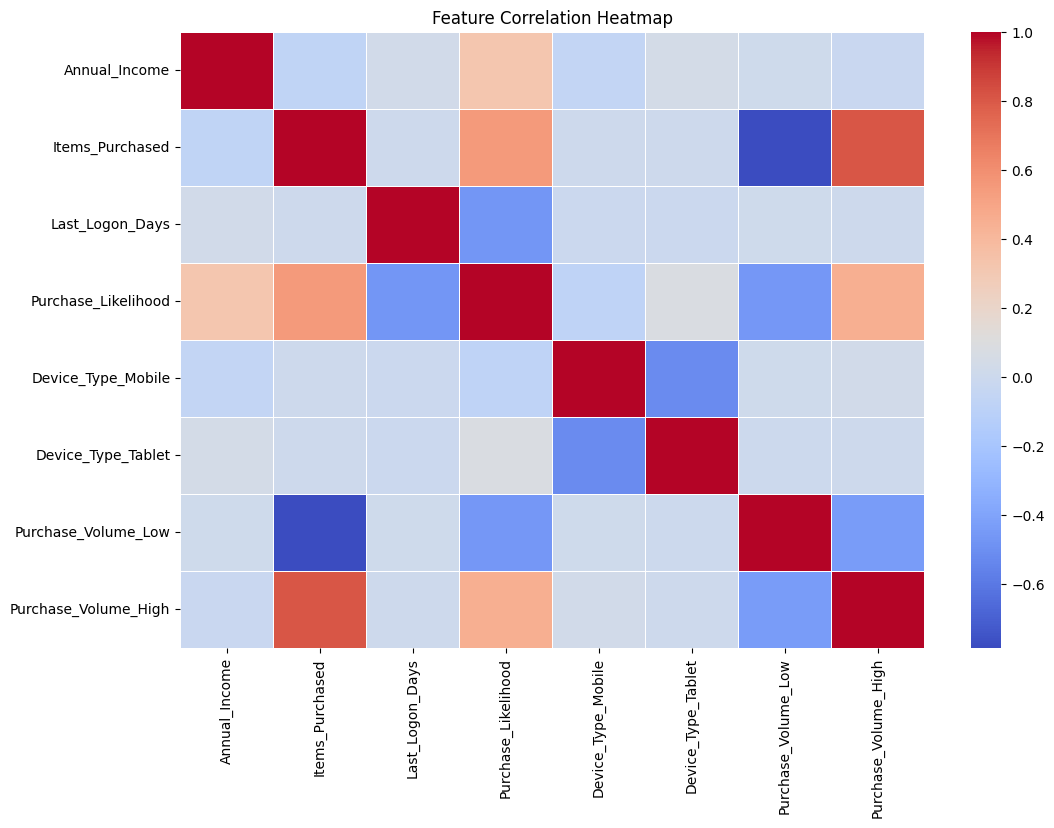

In [ ]:
# 3. Heatmap Visualization (New Section)
if 'Purchase_Likelihood' in df_final.columns:
    plt.figure(figsize=(12, 8))
    # Calculating correlation for the heatmap
    full_corr = df_final.corr()

    # Plotting the heatmap
    sns.heatmap(full_corr, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.show()

    # 4. Feature Selection based on Correlation
    corr_series = full_corr['Purchase_Likelihood'].abs()
    low_corr_cols = corr_series[(corr_series < 0.07) & (corr_series.index != 'Purchase_Likelihood')].index.tolist()

    if low_corr_cols:
        df_final = df_final.drop(columns=low_corr_cols)
        print("Dropped low-correlation columns:", low_corr_cols)

###Cell 12: Drop Unnecessary Columns
####Purpose: Remove columns that don't help prediction or are identifiers (Customer_ID) or redundant.



    cols_to_drop = [
    'Membership_Score',
    'Newsletter_Sub',
    'Customer_ID',
    'Purchase_Date'
    ]
*   Just a list of columns we want to remove
*   Why drop these?
      * Customer_ID: Just an identifier, not a feature
      * Purchase_Date: Would need special processing (date engineering)
      * Membership_Score: Might be redundant with other features
      * Newsletter_Sub: Doesn't help prediction




    df_final = df.drop(columns=cols_to_drop)
  

*   df.drop() - Removes specified columns
*   columns=cols_to_drop - The list we just defined
*   Stores result in df_final (new variable)



In [ ]:
df_final = df.drop(columns=['Membership_Score', 'Newsletter_Sub', 'Customer_ID', 'Purchase_Date'])
print(f"Final shape: {df_final.shape}")
print(f"Final columns: {df_final.columns.tolist()}")

Final shape: (286, 25)
Final columns: ['Age', 'Annual_Income', 'Total_Spend', 'Items_Purchased', 'Last_Logon_Days', 'Promo_User', 'Support_Calls', 'Purchase_Likelihood', 'Tax_Rate', 'Gender_F', 'Gender_Fem', 'Gender_Female', 'Gender_M', 'Gender_Male', 'Gender_m', 'Device_Type_Desktop', 'Device_Type_Mobile', 'Device_Type_Tablet', 'Store_Region_East', 'Store_Region_North', 'Store_Region_South', 'Store_Region_West', 'Purchase_Volume_Low', 'Purchase_Volume_Medium', 'Purchase_Volume_High']


###Cell 13: Save Cleaned Data
###Purpose: Export the cleaned dataset so you can use it for modeling.

    df_final.to_csv('cleaned_knn_data.csv', index=False)

*   to_csv() - Saves dataframe as CSV file
*   'cleaned_knn_data.csv' - Filename
*   index=False - Don't save row numbers as a column
*   Result: Creates a new file you can download



    print("Data Preparation Complete. Final shape:", df_final.shape)


*   Prints a message
*   df_final.shape - Shows (rows, columns) as a tuple
*   Confirms the pipeline finished successfully





In [ ]:
df_final.to_csv('cleaned_knn_data.csv', index=False)
print("Saved cleaned dataset!")

Saved cleaned dataset!


#Phase 3


##Baseline k-NN (Raw Dataset)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the adjusted dataset
df_raw = pd.read_csv('adjusted_noisy_knn_300.csv')

# --- Baseline Preparation ---
# 1. Keep only numeric columns (this automatically drops string fields)
# 2. Drop rows with any remaining NaN values
df_active = df_raw.select_dtypes(include=[np.number]).dropna()

# Separate Features (X) and Target (y)
# Ensure the target column 'Purchase_Likelihood' exists in your dataset
X_naive = df_active.drop(columns=['Purchase_Likelihood'])
y_naive = df_active['Purchase_Likelihood']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_naive, y_naive, test_size=0.2, random_state=42)

# Train k-NN (k=5)
knn_naive = KNeighborsClassifier(n_neighbors=5)
knn_naive.fit(X_train, y_train)

# Evaluate
y_pred = knn_naive.predict(X_test)
print("\n--- Baseline Accuracy (accuracy_score): y_test, y_pred[:2%] ---")
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nBaseline Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

df_raw.shape


--- Baseline Accuracy (accuracy_score): y_test, y_pred[:2%] ---
Baseline Accuracy: 42.86%

Baseline Confusion Matrix:
[[3 1]
 [7 3]]


(300, 15)

##Optimized k-NN (Prepared Dataset)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load the prepared dataset
# Replace "cleaned_knn_data.csv" or your specific file name
df_prepared = pd.read_csv("cleaned_data.csv")

# --- SAFETY CHECK: HANDLE REMAINING NaNs ---
# This clears any "ValueError: Input X contains NaN" if any slipped through
if df_prepared.isnull().values.any():
    print(f"Detecting {df_prepared.isnull().sum().sum()} missing values...")
    # Option 1: Drop them (if very few)
    # df_prepared = df_prepared.dropna()
    # Option 2: Fill them with median (numeric columns only)
    df_prepared = df_prepared.fillna(df_prepared.median(numeric_only=True))
    print("Missing values handled.")

# 2. Separate Features (X) and Target (y)
# Ensure the target column name matches your dataset
target_col = 'Purchase_Likelihood'
X = df_prepared.drop(columns=[target_col])
y = df_prepared[target_col]

# 3. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the k-NN Model (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = knn.predict(X_test)

print("\n--- Optimized k-NN Model Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

df_prepared.shape


--- Optimized k-NN Model Results ---
Accuracy Score: 89.66%

Confusion Matrix:
[[28  3]
 [ 3 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        31
           1       0.89      0.89      0.89        27

    accuracy                           0.90        58
   macro avg       0.90      0.90      0.90        58
weighted avg       0.90      0.90      0.90        58



(286, 8)

##Block 3: k-Parameter Optimization (k=1 to 20)

k= 1: Accuracy = 0.8793
k= 2: Accuracy = 0.8448
k= 3: Accuracy = 0.8966
k= 4: Accuracy = 0.8966
k= 5: Accuracy = 0.8966
k= 6: Accuracy = 0.9138
k= 7: Accuracy = 0.9138
k= 8: Accuracy = 0.8793
k= 9: Accuracy = 0.8621
k=10: Accuracy = 0.8793
k=11: Accuracy = 0.8448
k=12: Accuracy = 0.8448
k=13: Accuracy = 0.8103
k=14: Accuracy = 0.8103
k=15: Accuracy = 0.7931
k=16: Accuracy = 0.7931
k=17: Accuracy = 0.8103
k=18: Accuracy = 0.8103
k=19: Accuracy = 0.8276
k=20: Accuracy = 0.7759

✓ Optimal k: 6
✓ Best accuracy: 0.9138


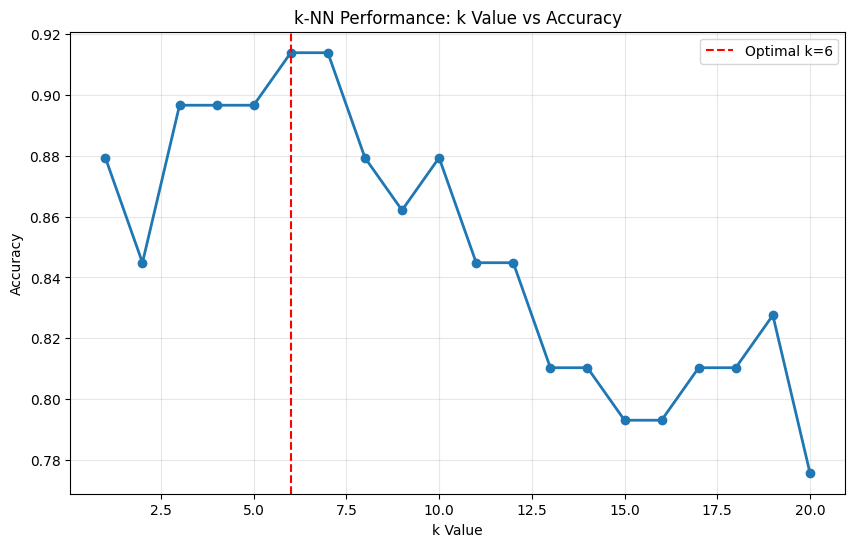

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred_temp)
    accuracies.append(acc)
    print(f"k={k:2d}: Accuracy = {acc:.4f}")

optimal_k = k_values[np.argmax(accuracies)]
optimal_accuracy = max(accuracies)

print(f"\n✓ Optimal k: {optimal_k}")
print(f"✓ Best accuracy: {optimal_accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel('k Value')
plt.ylabel('Accuracy')
plt.title('k-NN Performance: k Value vs Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()